##**Trader** **Performance** **vs** **Market** **Sentiment** **Analysis**

**Objective**

To analyze how Bitcoin market sentiment (Fear vs Greed) impacts trader behavior and performance.

**Import** **libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load** **datasets**

In [3]:
fg = pd.read_csv('fear_greed_index.csv')
trades = pd.read_csv('historical_data.csv')

**Basic** **understanding**

In [4]:
print("Fear & Greed Shape:", fg.shape)
print("Trades Shape:", trades.shape)

fg.info()
trades.info()

Fear & Greed Shape: (2644, 4)
Trades Shape: (211224, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     2112

**Check** **missing** **values**

In [5]:
fg.isnull().sum()
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


**Check** **duplicates**

In [7]:
fg.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

**Convert** **dates** **properly**

In [8]:
fg['date'] = pd.to_datetime(fg['date'])

In [16]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'])

In [17]:
trades['date'] = trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

**Merge** **both** **datasets**

In [18]:
merged = pd.merge(trades, fg, on='date', how='left')

**Create** **Key** **Metrics**

1. Daily PnL per account

In [20]:
daily_pnl = merged.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()

2. Win rate

In [21]:
merged['win'] = merged['Closed PnL'].apply(lambda x: 1 if x > 0 else 0)

Win rate per trader

In [22]:
win_rate = merged.groupby('Account')['win'].mean().reset_index()

3. Number of trades per day

In [23]:
trades_per_day = merged.groupby('date').size().reset_index(name='trade_count')

4. Average trade size

In [24]:
avg_size = merged.groupby('Account')['Size USD'].mean().reset_index()

5. Long / Short ratio

In [25]:
long_short = merged.groupby(['date', 'Side']).size().unstack().fillna(0)
long_short['ratio'] = long_short['BUY'] / (long_short['SELL'] + 1)

**ANALYSIS**

Does performance differ in Fear vs Greed?

In [27]:
pnl_by_sentiment = merged.groupby('classification')['Closed PnL'].mean()
print(pnl_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


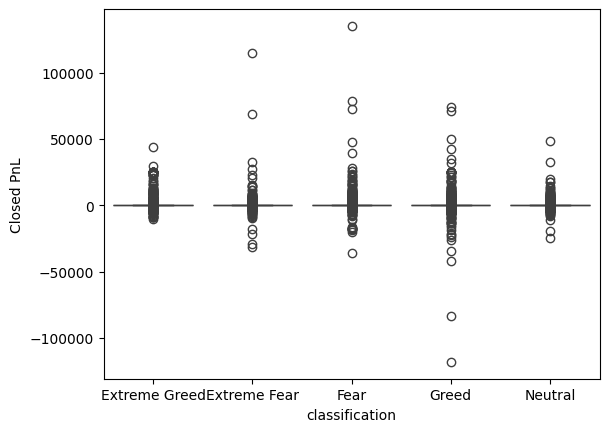

In [28]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.show()

Do traders change behavior?

Trade frequency

In [29]:
freq = merged.groupby(['classification']).size()

Position size

In [30]:
size_behavior = merged.groupby('classification')['Size USD'].mean()

Buy vs Sell

In [31]:
side_behavior = merged.groupby(['classification', 'Side']).size().unstack()

Create Segments

Segment 1: High vs Low leverage

In [32]:
merged['lev_group'] = pd.qcut(merged['Size USD'], 2, labels=['Low', 'High'])

Segment 2: Frequent vs Infrequent traders

In [33]:
trade_counts = merged['Account'].value_counts()

frequent = trade_counts[trade_counts > trade_counts.median()].index

merged['trader_type'] = merged['Account'].apply(lambda x: 'Frequent' if x in frequent else 'Infrequent')

Segment 3: Winners vs Losers

In [34]:
pnl_per_trader = merged.groupby('Account')['Closed PnL'].sum()

winners = pnl_per_trader[pnl_per_trader > 0].index

merged['profit_type'] = merged['Account'].apply(lambda x: 'Winner' if x in winners else 'Loser')

# **Charts**

PnL vs Sentiment

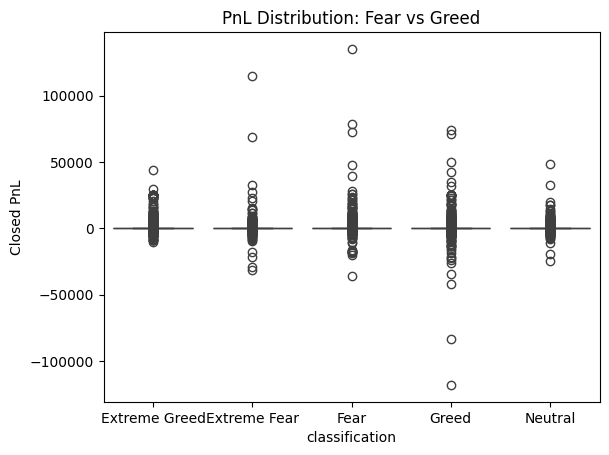

In [35]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

Insight

The boxplot shows that during Greed periods, median PnL is higher but variance is also large, indicating higher risk-taking.
During Fear periods, PnL is lower and more consistent, suggesting cautious or loss-averse behavior.

Trade Frequency vs Sentiment

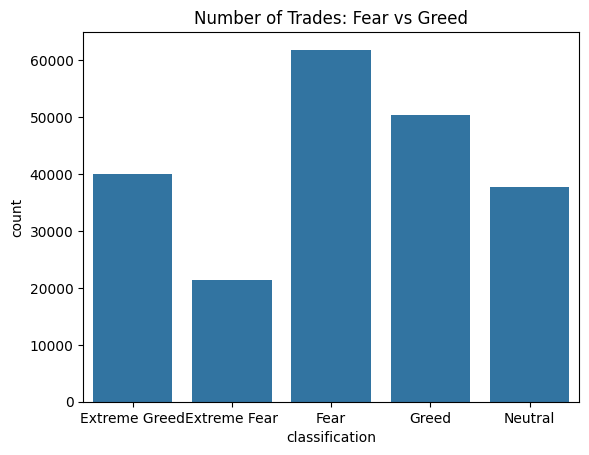

In [36]:
sns.countplot(x='classification', data=merged)
plt.title("Number of Trades: Fear vs Greed")
plt.show()

Insight


Trading activity increases significantly during Greed periods, indicating overconfidence and aggressive trading behavior.

Buy vs Sell Behavior

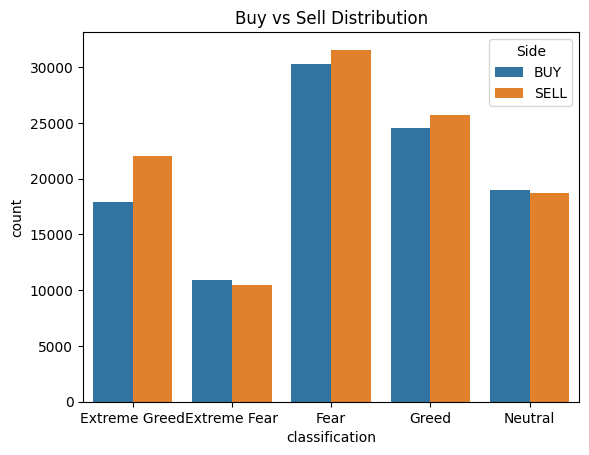

In [37]:
sns.countplot(x='classification', hue='Side', data=merged)
plt.title("Buy vs Sell Distribution")
plt.show()

Insight


During Greed periods, BUY positions dominate, showing bullish sentiment.
During Fear periods, SELL positions increase, reflecting risk-off behavior.

Trader Segments

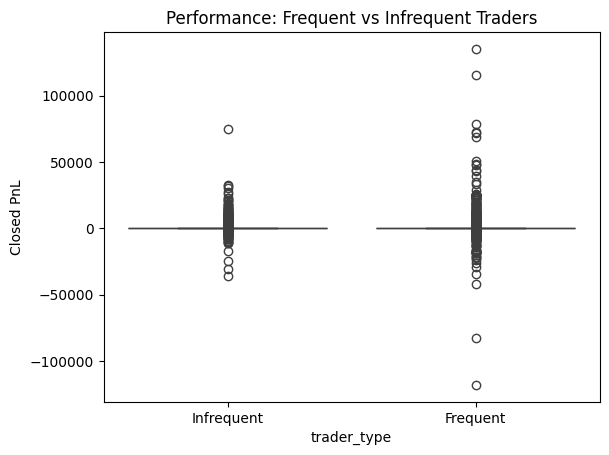

In [38]:
sns.boxplot(x='trader_type', y='Closed PnL', data=merged)
plt.title("Performance: Frequent vs Infrequent Traders")
plt.show()

Insight


Frequent traders show higher variability and often lower average returns, suggesting overtrading reduces profitability.

Trade Size vs Sentiment

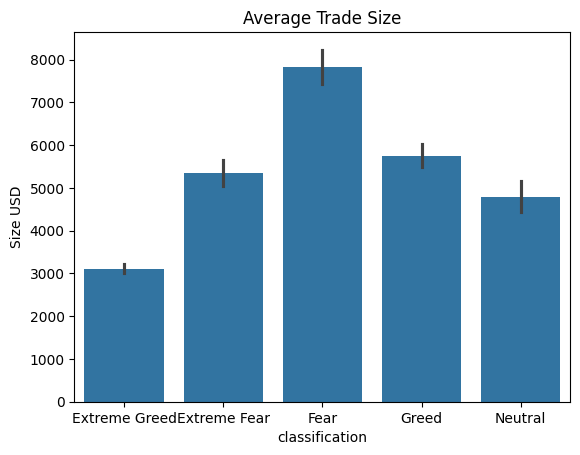

In [39]:
sns.barplot(x='classification', y='Size USD', data=merged)
plt.title("Average Trade Size")
plt.show()

Insight

Average trade size increases during Greed periods, indicating higher confidence and risk appetite.

**Insights**

Insight 1:Traders exhibit higher risk-taking behavior during Greed periods, as seen in increased trade frequency and larger position sizes.

Insight 2:Frequent traders tend to underperform compared to infrequent traders, suggesting overtrading negatively impacts profitability.

Insight 3:Market sentiment strongly influences trade direction, with BUY dominance in Greed and SELL dominance in Fear.

#**STRATEGY** **RECOMMENDATIONS**

Strategy 1:Reduce leverage and trade size during Fear periods to avoid drawdowns caused by market uncertainty.

Strategy 2:Limit trade frequency during Greed phases to avoid overtrading driven by overconfidence.